In [ ]:
# 실습 라이브러리(lib) 준비 — 교재 저장소에서 자동으로 받아옵니다 (Google Drive 불필요)
import os, sys
path = "/content/"
if not os.path.isdir(path + "lib"):
    !git clone -q --depth 1 https://github.com/AI-BoostCamp/ReinforcementLearning.git /content/_rl && cp -r /content/_rl/code/lib /content/lib && rm -rf /content/_rl
sys.path.append(path + "lib")
os.makedirs(path + "models/DRL", exist_ok=True)   # 학습된 모델 저장 위치 (세션 종료 시 사라짐)


In [2]:
from variable_print import p,ps,pst

# REINFORCE Algorithm 구현

In [3]:
import tensorflow as tf
import tensorflow_probability as tfp
import keras
from keras.layers import Dense,Input
from keras.models import Sequential
from keras.optimizers import Adam

import numpy as np
import gym
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

## Environment : CartPole 생성

In [4]:
import gymnasium as gym
env = gym.make("CartPole-v1", render_mode="rgb_array")
print(gym.__version__)  #0.25.2
print("="*10)
print('State space: ', env.observation_space)
print('Action space: ', env.action_space)
print("="*10)
s_dim = env.observation_space.shape[0]
a_dim = env.action_space.n
print(f"State dimension: {s_dim}")
print(f"Action dimension: {a_dim}")

1.2.0
State space:  Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space:  Discrete(2)
State dimension: 4
Action dimension: 2


## Neural Network 만들기  

In [5]:
def NeuralNetwork(state_size=4, action_size=2, hidden_size=30, learning_rate=0.001):
    model = Sequential()
    model.add(Input(shape=(state_size,)))
    model.add(Dense(hidden_size, activation='relu'))
    model.add(Dense(hidden_size, activation='relu'))
    model.add(Dense(action_size, activation='softmax'))
    return model

In [6]:
net = NeuralNetwork()
net.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            62 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142 (4.46 KB)

 Trainable params: 1,142 (4.46 KB)

 Non-trainable params: 0 (0.00 B)

## REINFORCE Agent 만들기  


In [7]:
#from keras.src.optimizers import learning_rate_schedule

class REINFORCE:
    def __init__(self, policy_model,
                 gamma = 1.0, lr = 0.001):
        super(REINFORCE, self).__init__()
        self.model = policy_model
        self.gamma = gamma
        self.optimizer = Adam(learning_rate=lr) # NN optimizer
        self._eps = 1e-25

    def get_action(self, state): # action <- sampling(model(state))
        prob_a = self.model.predict(state, batch_size=1,verbose=0).flatten()
        return np.random.choice(2, 1, p=prob_a)[0] #p(left, right)에서 sampling

    def _pre_process_inputs(self,episode):# epi. trejectory를 역순으로 재배치
        states, actions, rewards = episode
        states = np.flip(states,axis=0) #(steps,s)
        actions = np.flip(actions)      #(steps,)
        rewards = np.flip(rewards)      #(steps,)
        return states, actions, rewards

    def loss(self, prob_a, action, gt):
        log_probability = tf.math.log(prob_a[0][action] + self._eps)
        loss = -log_probability * gt
        return loss

    # sample-by-sample update version of REINFORCE
    def update(self, episode):
        ## _pre_process_inputs: trajectory 순서 뒤집기,뒤부터 gamma적용하기 위해
        states, actions, rewards = self._pre_process_inputs(episode)
        g = tot_loss = 0
        for i,(s, a, r) in enumerate(zip(states, actions, rewards)): # step반복
            with tf.GradientTape() as tape:
                g = r + self.gamma * g                    # 현 setp에서 Gt 계산
                prob_a = self.model(s.reshape(1,4), training=True)#두action의 확률
                loss = self.loss(prob_a, a, g)            # -log(pi(selected_a))*Gt
            grads = tape.gradient(loss, self.model.trainable_variables)
            self.optimizer.apply_gradients(zip(grads, self.model.trainable_variables))
            tot_loss += loss
        return tot_loss/(i+1)

## Training

In [8]:
model_path = path+"models/DRL/reinforce_cartpole.keras"

In [9]:
%%time
net = NeuralNetwork()
agent = REINFORCE(net)

n_eps = 20 #150
print_every = 1
scores = [0]
losses =[]
max_score = 0

for ep in range(n_eps): # episode 반복
    s, info = env.reset()     # evn. 초기화
    cum_r = 0           # epi.내에서 reward sum
    states = []
    actions = []
    rewards = []
    while True:         # 하나의 episode 시행
        s = np.reshape(s, (1, 4))           # (bs,s)
        a = agent.get_action(s)             # plocy net. 출력에서 sampling한 action
        ns, r, done, info, _ = env.step(a)  # env. feedback
        states.append(s)                # trajectory 저장
        actions.append(a)               #
        rewards.append(r)               #
        s = ns                          # state update
        cum_r += r                      # epi. 길이 (epi.score)
        if done: break                  # Termination
    scores.append(cum_r)
    states = np.array(states).reshape(-1,4)  #(steps,s) # reshape
    actions = np.array(actions).reshape(-1,) #(steps,)  #
    rewards = np.array(rewards).reshape(-1,) #(steps,)  #
    episode = (states, actions, rewards)
    loss = agent.update(episode)        ## model Training
    losses.append(loss)
    mean_score = np.mean(scores[-min(10,len(scores)):])
    if ep % print_every == 0:
        print(f"Episode {ep} || mean_score: {mean_score:.1f} ||  Loss: {loss:.2f} ")
    if mean_score > max_score:
        max_score = mean_score
        # net.save(model_path)
        # print(f"  model saved..")
    if mean_score > 300 : break

Episode 0 || mean_score: 10.5 ||  Loss: 7.63 
Episode 1 || mean_score: 14.3 ||  Loss: 8.01 
Episode 2 || mean_score: 17.5 ||  Loss: 9.73 
Episode 3 || mean_score: 22.4 ||  Loss: 14.70 
Episode 4 || mean_score: 24.2 ||  Loss: 11.47 
Episode 5 || mean_score: 24.7 ||  Loss: 9.82 
Episode 6 || mean_score: 25.2 ||  Loss: 9.84 
Episode 7 || mean_score: 27.6 ||  Loss: 15.14 
Episode 8 || mean_score: 26.7 ||  Loss: 6.80 
Episode 9 || mean_score: 29.1 ||  Loss: 8.11 
Episode 10 || mean_score: 31.8 ||  Loss: 16.69 
Episode 11 || mean_score: 31.6 ||  Loss: 6.79 
Episode 12 || mean_score: 32.5 ||  Loss: 11.73 
Episode 13 || mean_score: 30.7 ||  Loss: 7.82 
Episode 14 || mean_score: 30.4 ||  Loss: 9.76 
Episode 15 || mean_score: 30.4 ||  Loss: 9.53 
Episode 16 || mean_score: 32.3 ||  Loss: 16.32 
Episode 17 || mean_score: 28.9 ||  Loss: 5.14 
Episode 18 || mean_score: 28.8 ||  Loss: 6.18 
Episode 19 || mean_score: 30.2 ||  Loss: 12.27 
CPU times: user 55.1 s, sys: 2.02 s, total: 57.1 s
Wall time: 5

In [ ]:
%%time
net = NeuralNetwork(state_size=s_dim, action_size=a_dim)
agent = REINFORCE(net)

n_eps = 150
print_every = 2
scores = [0]
losses =[]
mean_r = 0
max_score = 0

for ep in range(n_eps): # episode 반복
    s, info = env.reset()     # evn. 초기화
    cum_r = 0           # epi.내에서 reward sum
    states = []
    actions = []
    rewards = []
    while True:         # 하나의 episode 시행
        s = np.reshape(s, (1, 4))           # (bs,s)
        a = agent.get_action(s)             # plocy net. 출력에서 sampling한 action
        ns, r, done, info, _ = env.step(a)  # env. feedback
        states.append(s)                # trajectory 저장
        actions.append(a)               #
        rewards.append(r)               #
        s = ns                          # state update
        cum_r += r                      # epi. 길이 (epi.score)
        if done: break                  # Termination
    scores.append(cum_r)
    states = np.array(states).reshape(-1,4)  #(steps,s) # reshape
    actions = np.array(actions).reshape(-1,) #(steps,)  #
    rewards = np.array(rewards).reshape(-1,) #(steps,)  #
    episode = (states, actions, rewards)
    loss = agent.update(episode)        ## model Training
    losses.append(loss)
    mean_score = np.mean(scores[-min(10,len(scores)):])
    if ep % print_every == 0:
        print(f"Episode {ep} || mean_score: {mean_score:.1f} ||  Loss: {loss:.2f} ")
    if mean_score > max_score:
        max_score = mean_score
        net.save(model_path)
        print(f"  model saved..")
    if mean_score > 300 : break

Episode 0 || mean_score: 23.000 ||  Loss: 15.983362197875977 
Episode 2 || mean_score: 43.750 ||  Loss: 8.278721809387207 
Episode 4 || mean_score: 39.667 ||  Loss: 5.710756301879883 
Episode 6 || mean_score: 36.000 ||  Loss: 7.458217620849609 
Episode 8 || mean_score: 31.800 ||  Loss: 6.978595733642578 
Episode 10 || mean_score: 32.800 ||  Loss: 7.658785820007324 
Episode 12 || mean_score: 27.300 ||  Loss: 13.245869636535645 
Episode 14 || mean_score: 27.500 ||  Loss: 15.309503555297852 
Episode 16 || mean_score: 29.000 ||  Loss: 15.749323844909668 
Episode 18 || mean_score: 32.500 ||  Loss: 16.155759811401367 
Episode 20 || mean_score: 33.900 ||  Loss: 13.891341209411621 
Episode 22 || mean_score: 33.600 ||  Loss: 15.350932121276855 
Episode 24 || mean_score: 34.700 ||  Loss: 20.371639251708984 
Episode 26 || mean_score: 32.900 ||  Loss: 9.663989067077637 
Episode 28 || mean_score: 31.600 ||  Loss: 8.968448638916016 
Episode 30 || mean_score: 32.200 ||  Loss: 14.702527046203613 
Epis

Wall time: 24min 44s


In [ ]:
"""## 학습 결과 시각화"""
def plot_moving_avg(data, window_size):
    if not data: return
    moving_avg = np.convolve(data, np.ones(window_size)/window_size, mode='valid')
    plt.plot(moving_avg)

plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.plot(scores)
plot_moving_avg(scores,5)
plt.title(f'REINFORCE Scores, Max Avg Score: {max(scores):.2f}')
plt.xlabel('Episode')
plt.ylabel('Score')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(losses)
plot_moving_avg(losses,5)
plt.title('Training Loss')
plt.xlabel('Episode')
plt.ylabel('Loss')
plt.grid()
plt.show()

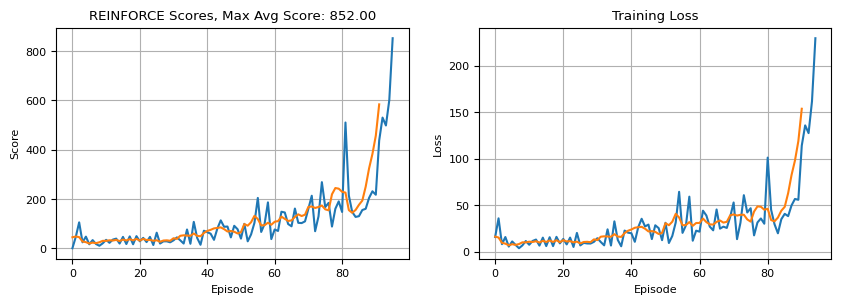

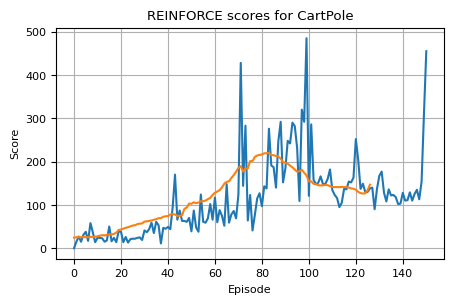

In [ ]:
#net.save(model_path)
net = keras.models.load_model(model_path)

## Evaluation

In [ ]:
%%capture
!pip install pyvirtualdisplay
!sudo apt-get update
!sudo apt-get install python-opengl
!sudo apt-get install -f
!sudo apt-get upgrade --fix-missing
!sudo apt-get install xvfb

In [ ]:
from pyvirtualdisplay import Display
virtual_display = Display(visible=0, size=(400, 300))
virtual_display.start()

In [ ]:
from render import  show_video, wrap_env, render_as_image

video_prefix = "REINFORCE"
env_v = wrap_env(env, path=path, name_prefix=video_prefix)

/usr/local/lib/python3.11/dist-packages/gym/wrappers/record_video.py:78: UserWarning: WARN: Overwriting existing videos at /content/gdrive/MyDrive/Colab Notebooks/video folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


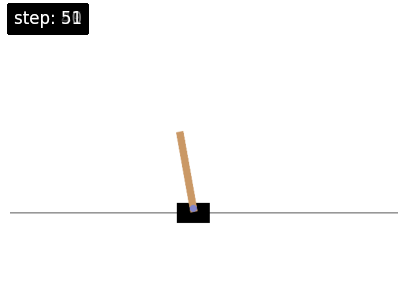

In [ ]:
state, _ = env_v.reset()
cnt = 0
while True:
    render_as_image(env_v,step=cnt)
    predict = net.predict(state.reshape(1,4),verbose=0)
    action = np.argmax(predict)
    state, reward, done, info, _ = env_v.step(action)
    if done or cnt > 50:  break;
    cnt += 1
env_v.close()

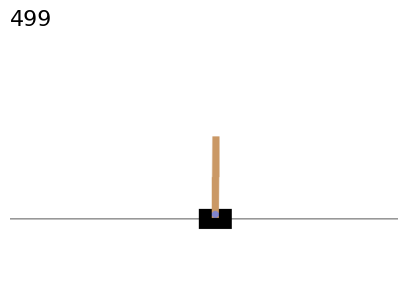

In [ ]:
show_video(path=path,name_prefix=video_prefix)

In [ ]:
show_video(path=path,name_prefix='REINFORCE')

/content/gdrive/MyDrive/Colab Notebooks/video/REINFORCE-episode-0.mp4
